#Setup

##CatDom

In [ ]:
import pandas as pd

In [ ]:
lingFeatsOfInterest = ['file'] + ['# of words', 'Type Token Ratio', 'Noun to Verb ratio', 'Propositional Density','Open Closed Words Ratio',  'Average sentence length', 'Suboordination Main Verb Implied','Proportion Fillers','Proportion Repetitions' ]

In [ ]:
def simplifyID(id):
  return id.split('_')[0]

In [ ]:
catDomLingDF = pd.read_csv('CAT_Dom_LinguisticFeatures.csv')
catDomLingDF = catDomLingDF[lingFeatsOfInterest]
catDomLingDF['file'] = catDomLingDF['file'].apply(simplifyID)
#rename 'file' column to 'File' using .rename
catDomLingDF.rename(columns={'file': 'File'}, inplace=True)
catDomLingDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions
0,BILP007,110.0,0.572727,1.000000,0.472727,0.750000,11.000000,0.900000,0.081818,0.009091
1,BILP008,184.0,0.478261,1.166667,0.467391,0.844660,10.823529,0.764706,0.021739,0.000000
2,BILP010,172.0,0.465116,0.461538,0.534884,0.927083,7.478261,0.521739,0.058140,0.011628
3,BILP011,77.0,0.584416,2.000000,0.324675,0.860465,7.700000,0.500000,0.038961,0.000000
4,BILP012,103.0,0.543689,1.285714,0.398058,0.714286,8.583333,0.500000,0.048544,0.009709


In [ ]:
catDomCLANDF = pd.read_csv('CAT_DOM_CLAN_Output.eval.xls.csv')[['File','retracing']]
catDomCLANDF['File'] = catDomCLANDF['File'].apply(simplifyID)
catDomCLANDF.head()

,File,retracing
0,BILP007,3
1,BILP008,2
2,BILP010,4
3,BILP011,1
4,BILP012,5


In [ ]:
catDomFragmentDF = pd.read_csv('Cat_Dom_Fragment.xls.csv')[['File','Token']]
catDomFragmentDF['File'] = catDomFragmentDF['File'].apply(simplifyID)
#rename token column to part-word repetition
catDomFragmentDF.columns = ['File','part-word repetitions']
catDomFragmentDF.head()

,File,part-word repetitions
0,BILP007,5
1,BILP008,2
2,BILP010,5
3,BILP011,3
4,BILP012,5


In [ ]:
#combine catDomLingDF, catDomCLANDF,catDomFragmentDF
catDomDF = catDomLingDF.merge(catDomCLANDF, on='File').merge(catDomFragmentDF, on='File')
#divide retracing, repetition and part-word repetition columns by '# of words' column
catDomDF['retracing'] = catDomDF['retracing'] / catDomDF['# of words']
catDomDF['part-word repetitions'] = catDomDF['part-word repetitions'] / catDomDF['# of words']
catDomDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions
0,BILP007,110.0,0.572727,1.000000,0.472727,0.750000,11.000000,0.900000,0.081818,0.009091,0.027273,0.045455
1,BILP008,184.0,0.478261,1.166667,0.467391,0.844660,10.823529,0.764706,0.021739,0.000000,0.010870,0.010870
2,BILP010,172.0,0.465116,0.461538,0.534884,0.927083,7.478261,0.521739,0.058140,0.011628,0.023256,0.029070
3,BILP011,77.0,0.584416,2.000000,0.324675,0.860465,7.700000,0.500000,0.038961,0.000000,0.012987,0.038961
4,BILP012,103.0,0.543689,1.285714,0.398058,0.714286,8.583333,0.500000,0.048544,0.009709,0.048544,0.048544


In [ ]:
catDomDF.shape

(23, 12)

##Cat Non-Dom

In [ ]:
catNonDomLingDF = pd.read_csv('CAT_NotDom_LinguisticFeatures.csv')
catNonDomLingDF = catNonDomLingDF[lingFeatsOfInterest]
catNonDomLingDF['file'] = catNonDomLingDF['file'].apply(simplifyID)
#rename 'file' column to 'File' using .rename
catNonDomLingDF.rename(columns={'file': 'File'}, inplace=True)
print(catNonDomLingDF.shape)

(11, 10)


In [ ]:
catNotDomCLANDF = pd.read_csv('CAT_NotDOM_CLAN_Output.eval.csv')[['File','retracing']]
catNotDomCLANDF['File'] = catNotDomCLANDF['File'].apply(simplifyID)
catNotDomCLANDF = catNotDomCLANDF[catNotDomCLANDF['File'].isin(list(catNonDomLingDF['File']))]
print(catNotDomCLANDF.shape)

(11, 2)


In [ ]:
catNotDomCLANDF.head()

,File,retracing
0,BILP006,11
1,BILP009,0
2,BILP013,8
3,BILP022,9
4,BILP024,14


In [ ]:
catNotDomFragmentDF = pd.read_csv('Cat_NotDom_Fragment.xls.csv', encoding='latin1')[['File','Token']]
catNotDomFragmentDF['File'] = catNotDomFragmentDF['File'].apply(simplifyID)
#rename token column to part-word repetition
catNotDomFragmentDF.columns = ['File','part-word repetitions']
catNotDomFragmentDF = catNotDomFragmentDF[catNotDomFragmentDF['File'].isin(list(catNonDomLingDF['File']))]
print(catNotDomFragmentDF.shape)

(11, 2)


In [ ]:
catNotDomDF = catNonDomLingDF.merge(catNotDomCLANDF, on='File').merge(catNotDomFragmentDF, on='File')
#divide retracing, repetition and part-word repetition columns by '# of words' column
catNotDomDF['retracing'] = catNotDomDF['retracing'] / catNotDomDF['# of words']
#catNotDomDF['repetition'] = catNotDomDF['repetition'] / catNotDomDF['# of words']
catNotDomDF['part-word repetitions'] = catNotDomDF['part-word repetitions'] / catNotDomDF['# of words']
catNotDomDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions
0,BILP006,206.0,0.432039,1.235294,0.417476,0.811966,7.103448,0.379310,0.024272,0.004854,0.053398,0.019417
1,BILP009,76.0,0.592105,1.066667,0.421053,0.744681,9.500000,0.625000,0.078947,0.000000,0.000000,0.000000
2,BILP013,260.0,0.453846,1.238095,0.438462,0.872340,8.965517,0.517241,0.015385,0.007692,0.030769,0.011538
3,BILP022,266.0,0.439850,0.977778,0.469925,0.785714,12.666667,1.190476,0.030075,0.003759,0.033835,0.067669
4,BILP024,180.0,0.544444,1.064516,0.433333,0.669492,10.000000,0.611111,0.083333,0.005556,0.077778,0.044444


In [ ]:
catNotDomDF.shape

(11, 12)

##Combine

In [ ]:
catLingDF = pd.concat([catDomDF, catNotDomDF])
catLingDF.head()

,File,# of words,Type Token Ratio,Noun to Verb ratio,Propositional Density,Open Closed Words Ratio,Average sentence length,Suboordination Main Verb Implied,Proportion Fillers,Proportion Repetitions,retracing,part-word repetitions
0,BILP007,110.0,0.572727,1.000000,0.472727,0.750000,11.000000,0.900000,0.081818,0.009091,0.027273,0.045455
1,BILP008,184.0,0.478261,1.166667,0.467391,0.844660,10.823529,0.764706,0.021739,0.000000,0.010870,0.010870
2,BILP010,172.0,0.465116,0.461538,0.534884,0.927083,7.478261,0.521739,0.058140,0.011628,0.023256,0.029070
3,BILP011,77.0,0.584416,2.000000,0.324675,0.860465,7.700000,0.500000,0.038961,0.000000,0.012987,0.038961
4,BILP012,103.0,0.543689,1.285714,0.398058,0.714286,8.583333,0.500000,0.048544,0.009709,0.048544,0.048544


In [ ]:
sampleNames = list(catLingDF['File'])
print(sampleNames)

['BILP007', 'BILP008', 'BILP010', 'BILP011', 'BILP012', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP025', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE010', 'BISE011', 'BISE014', 'BISE019', 'BILP006', 'BILP009', 'BILP013', 'BILP022', 'BILP024', 'BILP026', 'BISE004', 'BISE005', 'BISE013', 'BISE016', 'BISE018']


In [ ]:
catLingDF.shape

(34, 12)

In [ ]:
data_X = catLingDF.drop(columns=['File'])
data_X.shape

(34, 11)

In [ ]:
def getClass(filename):
  if 'BISE' in filename:
    return 'nfv'
  if 'BILP' in filename:
    return 'lv'
  if 'BIOBS003' in filename or 'BIOBS005' in filename:
    return 'lv'
  if 'BIOBS004' in filename:
    return 'nfv'

In [ ]:
dataY = catLingDF['File'].apply(getClass)
dataY.shape

(34,)

In [ ]:
from collections import Counter
Counter(dataY)

Counter({'lv': 24, 'nfv': 10})

In [ ]:
data_Y = [0 if y == 'nfv' else 1 for y in dataY ]
print(data_Y)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

#ML Methods

In [ ]:
print(data_Y)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


Extra functionalities: see predicted time needed, each fold's best model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

In [ ]:
def looNCVWithTiming(param_grid, clf):
  import numpy as np
  import pandas as pd
  from sklearn.model_selection import GridSearchCV, LeaveOneOut
  from sklearn.inspection import permutation_importance
  from sklearn.metrics import accuracy_score
  from tqdm import tqdm
  import time
  from sklearn.model_selection import cross_val_predict
  from sklearn.metrics import confusion_matrix
  from sklearn.metrics import classification_report
  X = data_X
  y = np.array(data_Y)

# --- Storage ---
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()
  numInnerFolds = 5

  print("Running nested LOO CV")
  from sklearn.preprocessing import StandardScaler
  from sklearn.decomposition import PCA
  from sklearn.neural_network import MLPClassifier
  from sklearn.pipeline import Pipeline

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    start_time = time.time()
    #scaler = StandardScaler()
    grid_search = GridSearchCV(clf, param_grid, cv=numInnerFolds, scoring='f1_macro',n_jobs=-1) #n_jobs ensures parrallelization speedup
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print(f"Best params for outer fold {test_idx}: {grid_search.best_params_}")

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1] #1 means P(aphasia)
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: cv loop lasted {elapsed:.2f} seconds")

# --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=['nfvPPA', 'lvPPA']))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)

  from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
  import numpy as np
  import matplotlib.pyplot as plt
  fpr, tpr, thresholds = roc_curve(data_Y, test_preds_probs)
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend(loc='lower right')
  plt.grid()
  plt.show()

# Post-Hoc Threshold Tuning
  optimal_idx = np.argmax(tpr - fpr)
  optimal_threshold = thresholds[optimal_idx]
  print(f"Optimal Threshold: {optimal_threshold}")

# Apply the optimal threshold
  adjusted_predictions = (test_preds_probs >= optimal_threshold).astype(int)
  print("Predictions using adjusted threshold:", adjusted_predictions)

# Evaluate the new predictions
  print("Confusion Matrix with Adjusted Threshold:")
  print(confusion_matrix(data_Y, adjusted_predictions))
  print("Classification Report with Adjusted Threshold:")
  print(classification_report(data_Y, adjusted_predictions, target_names=['nfvPPA', 'lvPPA']))

  print("Prettier confusion matrix for adjusted threshold:")
  generateBetterConfusionMatrix(test_true, adjusted_predictions)
  print("Prettier confusion matrix for default threshold:")
  generateBetterConfusionMatrix(test_true, test_preds)

In [ ]:
def generateBetterConfusionMatrix(test_true,test_preds):
  import matplotlib.pyplot as plt
  import numpy as np
  from sklearn.metrics import confusion_matrix

# Compute confusion matrix and normalized version
  cm = confusion_matrix(test_true, test_preds)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  row_totals = cm.sum(axis=1)


  plt.rcParams.update({
    'font.size': 14,          # base font size
    'axes.labelsize': 16,     # x/y label size
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
  })


# Plot setup
  fig, ax = plt.subplots()
  im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)  # Use 'Blues'
  cbar = plt.colorbar(im, ax=ax)

# Axis setup
  class_names = ['nfvPPA', 'lvPPA']
  ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True diagnosis',
       xlabel='Predicted diagnosis')
  plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate each cell
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        total = row_totals[i]
        percent = cm_normalized[i, j] * 100

        # Get brightness to set text color (luminance rule of thumb)
        brightness = im.cmap(cm_normalized[i, j])[:3]  # RGB
        luminance = 0.299 * brightness[0] + 0.587 * brightness[1] + 0.114 * brightness[2]
        text_color = 'black' if luminance > 0.5 else 'white'

        ax.text(j, i, f'{percent:.0f}% ({count}/{total})',
                ha='center', va='center', color=text_color, fontsize=14)

  plt.tight_layout()
  plt.show()


#Decision Tree (70%)

In [ ]:
decision_tree_param_grid = {
    "class_weight": ["balanced", None],
    "criterion": ["gini"],
    "max_depth": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:04<02:37,  4.76s/it]

Best params for outer fold [0]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt'}
Test idx 0: cv loop lasted 4.76 seconds


Outer folds:   6%|▌         | 2/34 [00:05<01:14,  2.32s/it]

Best params for outer fold [1]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt'}
Test idx 1: cv loop lasted 0.61 seconds


...

Best params for outer fold [31]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt'}
Test idx 31: cv loop lasted 0.61 seconds


Outer folds:  97%|█████████▋| 33/34 [00:26<00:00,  1.55it/s]

Best params for outer fold [32]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt'}
Test idx 32: cv loop lasted 0.66 seconds


Outer folds: 100%|██████████| 34/34 [00:27<00:00,  1.23it/s]

Best params for outer fold [33]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt'}
Test idx 33: cv loop lasted 1.00 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.60      0.60      0.60        10
       lvPPA       0.83      0.83      0.83        24

    accuracy                           0.76        34
   macro avg       0.72      0.72      0.72        34
weighted avg       0.76      0.76      0.76        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0)]
Evaluati

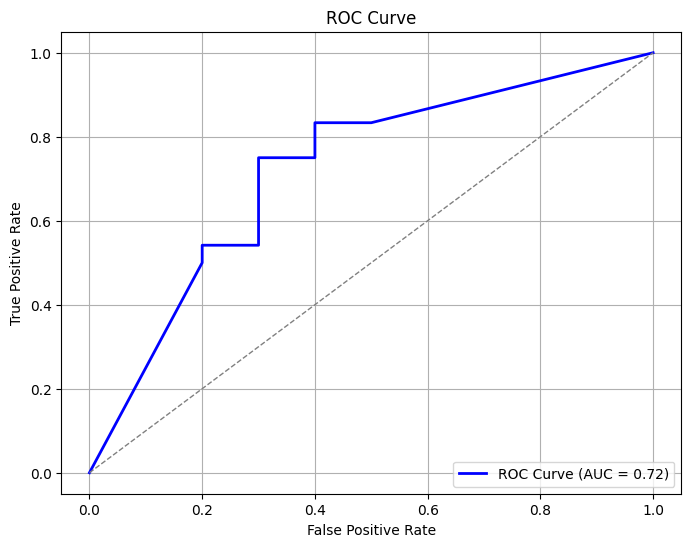

Optimal Threshold: 0.75
Predictions using adjusted threshold: [1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0]
Confusion Matrix with Adjusted Threshold:
[[ 7  3]
 [ 6 18]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.54      0.70      0.61        10
       lvPPA       0.86      0.75      0.80        24

    accuracy                           0.74        34
   macro avg       0.70      0.72      0.70        34
weighted avg       0.76      0.74      0.74        34

Prettier confusion matrix for adjusted threshold:


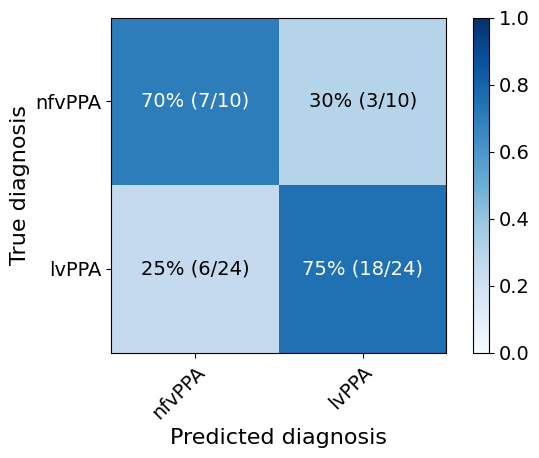

Prettier confusion matrix for default threshold:


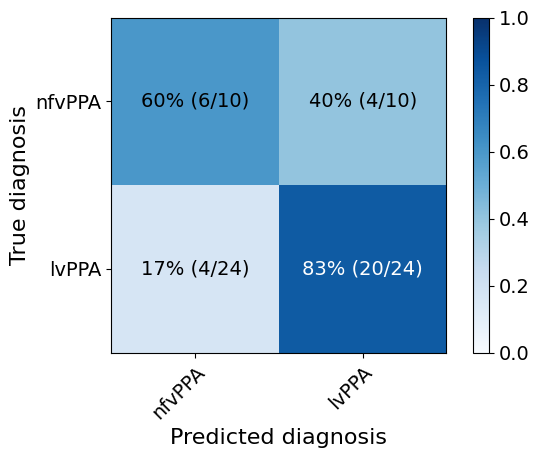

In [ ]:
looNCVWithTiming(param_grid=decision_tree_param_grid, clf=DecisionTreeClassifier(random_state=0))

#Gradient Boosting (74%)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:03<02:09,  3.93s/it]

Best params for outer fold [0]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 25}
Test idx 0: cv loop lasted 3.93 seconds


Outer folds:   6%|▌         | 2/34 [00:07<01:54,  3.58s/it]

Best params for outer fold [1]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 25}
Test idx 1: cv loop lasted 3.34 seconds


...

Best params for outer fold [31]: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 100}
Test idx 31: cv loop lasted 3.24 seconds


Outer folds:  97%|█████████▋| 33/34 [02:05<00:03,  3.87s/it]

Best params for outer fold [32]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 100}
Test idx 32: cv loop lasted 4.52 seconds


Outer folds: 100%|██████████| 34/34 [02:09<00:00,  3.81s/it]

Best params for outer fold [33]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 100}
Test idx 33: cv loop lasted 3.62 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.83      0.50      0.62        10
       lvPPA       0.82      0.96      0.88        24

    accuracy                           0.82        34
   macro avg       0.83      0.73      0.75        34
weighted avg       0.82      0.82      0.81        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]
Evaluation true: [np.int64(1), 

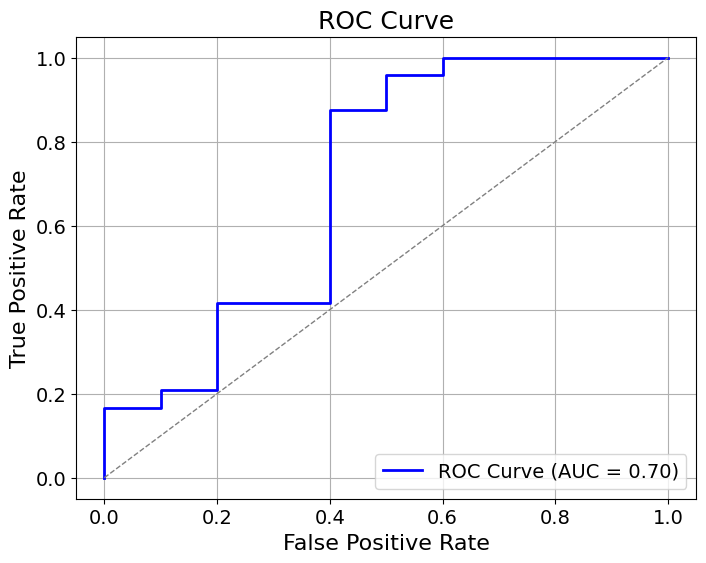

Optimal Threshold: 0.7334625598584378
Predictions using adjusted threshold: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0]
Confusion Matrix with Adjusted Threshold:
[[ 6  4]
 [ 3 21]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.67      0.60      0.63        10
       lvPPA       0.84      0.88      0.86        24

    accuracy                           0.79        34
   macro avg       0.75      0.74      0.74        34
weighted avg       0.79      0.79      0.79        34

Prettier confusion matrix for adjusted threshold:


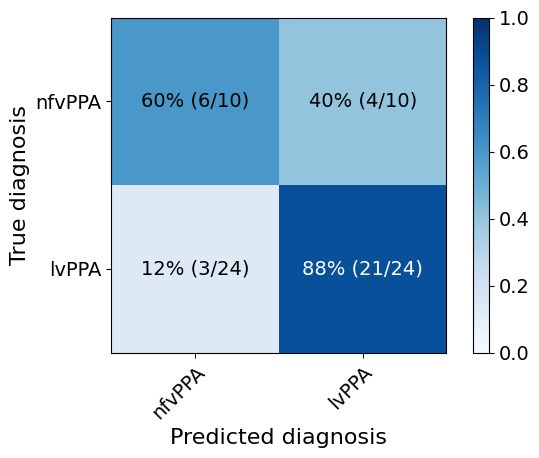

Prettier confusion matrix for default threshold:


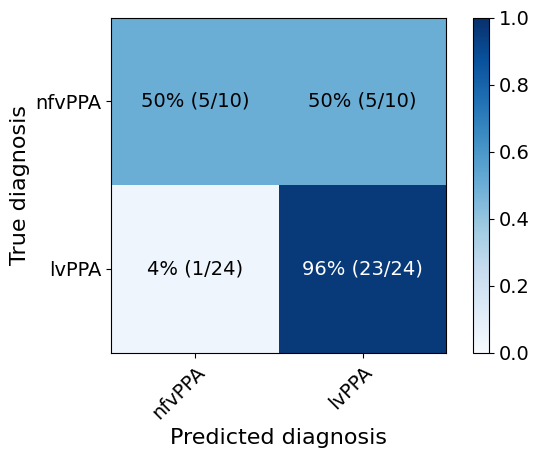

In [ ]:
gbcParamGrid = {
    "n_estimators": [25, 50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2]
}
looNCVWithTiming(param_grid=gbcParamGrid, clf=GradientBoostingClassifier(random_state=0))

#SVM (67%)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA
reducer = PCA(random_state=0)
from sklearn.svm import SVC
clf = SVC(random_state=0,class_weight='balanced',probability=True)
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('pca', reducer), ('SVM', clf)])
linear_svm_grid = {
    "SVM__kernel": ["linear"],
    "SVM__C": [0.01, 0.1, 1.0],
    "SVM__class_weight": ["balanced", None]
}
rbf_svm_grid = {
    "pca__n_components": [1,2,3],
    "SVM__kernel": ["rbf"],
    "SVM__C": [0.1, 1.0],
    "SVM__gamma": ["scale"],
    "SVM__class_weight": ["balanced", None]
}
svmParamGrid = [linear_svm_grid, rbf_svm_grid]

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:00<00:32,  1.00it/s]

Best params for outer fold [0]: {'SVM__C': 0.01, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 0: cv loop lasted 1.00 seconds


Outer folds:   6%|▌         | 2/34 [00:01<00:30,  1.04it/s]

Best params for outer fold [1]: {'SVM__C': 1.0, 'SVM__class_weight': 'balanced', 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf', 'pca__n_components': 3}
Test idx 1: cv loop lasted 0.94 seconds


...

Best params for outer fold [31]: {'SVM__C': 0.01, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 31: cv loop lasted 1.62 seconds


Outer folds:  97%|█████████▋| 33/34 [00:37<00:01,  1.38s/it]

Best params for outer fold [32]: {'SVM__C': 0.01, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 32: cv loop lasted 1.76 seconds


Outer folds: 100%|██████████| 34/34 [00:38<00:00,  1.14s/it]

Best params for outer fold [33]: {'SVM__C': 0.01, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 33: cv loop lasted 1.05 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.57      0.40      0.47        10
       lvPPA       0.78      0.88      0.82        24

    accuracy                           0.74        34
   macro avg       0.67      0.64      0.65        34
weighted avg       0.72      0.74      0.72        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]
Evaluation true: 

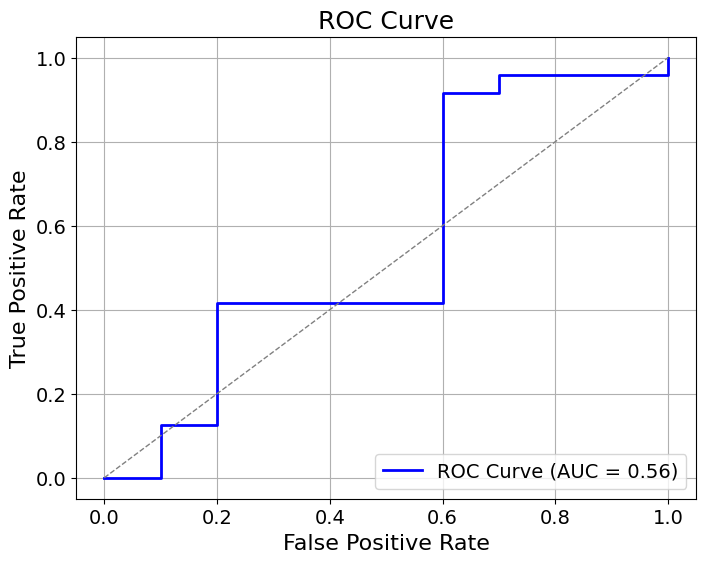

Optimal Threshold: 0.6831222483274485
Predictions using adjusted threshold: [1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1]
Confusion Matrix with Adjusted Threshold:
[[ 4  6]
 [ 2 22]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.67      0.40      0.50        10
       lvPPA       0.79      0.92      0.85        24

    accuracy                           0.76        34
   macro avg       0.73      0.66      0.67        34
weighted avg       0.75      0.76      0.74        34

Prettier confusion matrix for adjusted threshold:


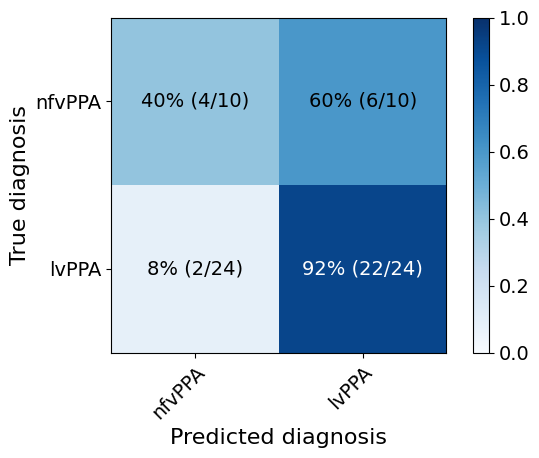

Prettier confusion matrix for default threshold:


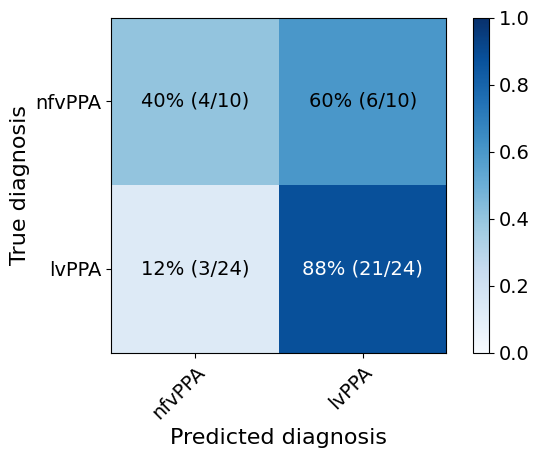

In [ ]:
looNCVWithTiming(param_grid=svmParamGrid, clf=pipe)

#Shallow Neural Net (73%)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(
    random_state=0,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10
)

In [ ]:
snn_param_grid = {
    "MLP__hidden_layer_sizes": [
        (5,), #minimal nonlinearity
        (10,), #moderate flexibility
        (15,) #Hidden units ≲ number of features
    ],
    "MLP__activation": [
        "tanh", #Zero-centered, stable for small datasets
        "relu" #default activation function
    ],
    "MLP__alpha": [
        1e-4,
        1e-3,
        1e-2
    ],
    "MLP__solver": [
        "adam"
    ]
}


Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:01<00:57,  1.73s/it]

Best params for outer fold [0]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 0: cv loop lasted 1.73 seconds


Outer folds:   6%|▌         | 2/34 [00:03<00:56,  1.76s/it]

Best params for outer fold [1]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 1: cv loop lasted 1.78 seconds


...

Best params for outer fold [31]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 31: cv loop lasted 1.75 seconds


Outer folds:  97%|█████████▋| 33/34 [01:05<00:02,  2.08s/it]

Best params for outer fold [32]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 32: cv loop lasted 2.62 seconds


Outer folds: 100%|██████████| 34/34 [01:08<00:00,  2.01s/it]

Best params for outer fold [33]: {'MLP__activation': 'tanh', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (5,), 'MLP__solver': 'adam'}
Test idx 33: cv loop lasted 2.58 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.50      0.70      0.58        10
       lvPPA       0.85      0.71      0.77        24

    accuracy                           0.71        34
   macro avg       0.68      0.70      0.68        34
weighted avg       0.75      0.71      0.72        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1),

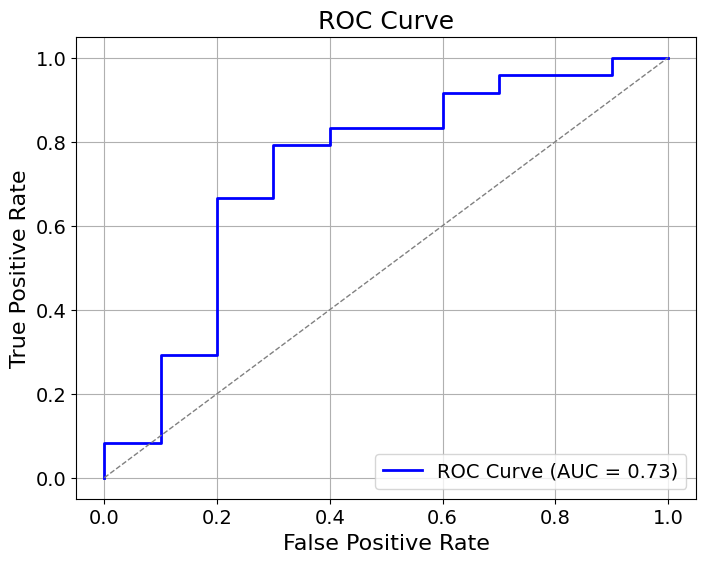

Optimal Threshold: 0.42545039425203357
Predictions using adjusted threshold: [1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 0]
Confusion Matrix with Adjusted Threshold:
[[ 7  3]
 [ 5 19]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.58      0.70      0.64        10
       lvPPA       0.86      0.79      0.83        24

    accuracy                           0.76        34
   macro avg       0.72      0.75      0.73        34
weighted avg       0.78      0.76      0.77        34

Prettier confusion matrix for adjusted threshold:


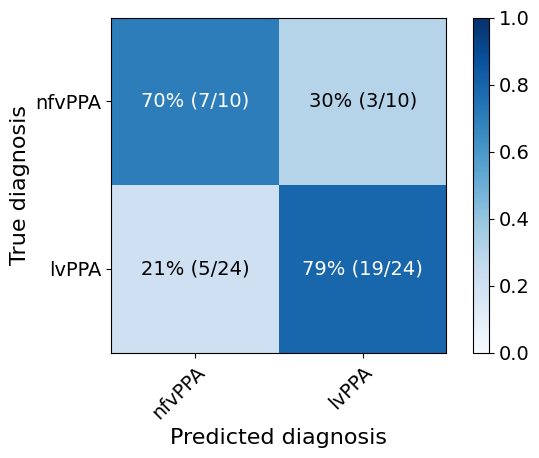

Prettier confusion matrix for default threshold:


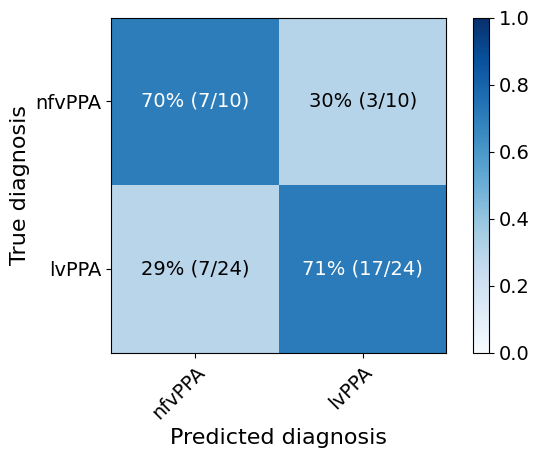

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('MLP', clf)])
looNCVWithTiming(param_grid=snn_param_grid, clf=pipe)

#Most Freq Baseline (41%)



In [ ]:
#import DummyClassifier from sklearn
from sklearn.dummy import DummyClassifier
#import cross_val_predict from sklearn
from sklearn.model_selection import cross_val_predict

In [ ]:
mostfreq_baseline = DummyClassifier(strategy="most_frequent",random_state=99)
predicted = cross_val_predict(mostfreq_baseline, data_X, data_Y, cv=5)
print(predicted)
print(confusion_matrix(data_Y, predicted))
print(classification_report(data_Y, predicted,target_names=['Non-Aphasia','Aphasia']))
print(accuracy_score(data_Y, predicted))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[ 0 25]
 [ 0 40]]
              precision    recall  f1-score   support

 Non-Aphasia       0.00      0.00      0.00        25
     Aphasia       0.62      1.00      0.76        40

    accuracy                           0.62        65
   macro avg       0.31      0.50      0.38        65
weighted avg       0.38      0.62      0.47        65

0.6153846153846154


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Permutation analysis

##General code

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

def looNCVPermutationImportance(clf, param_grid, threshold, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA']):
  X = data_X
  y = np.array(data_Y)
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()

  print("Running nested LOO CV with permutation importance...")

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    #print(train_idx, test_idx)
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    gridSearch = GridSearchCV(clf, param_grid, cv=5, scoring=criterion)
    gridSearch.fit(X_train, y_train)
    best_model = gridSearch.best_estimator_

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)

    # Permutation importance (with timing)
    start_time = time.time()
    result = permutation_importance(
        best_model,
        X_train,
        y_train,
        n_repeats=n_repeats,
        random_state=42,
        scoring=criterion,
        n_jobs=-1
    )
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: Permutation importance took {elapsed:.2f} seconds")

    perm_importances_per_fold.append(result.importances_mean)

# --- Aggregate permutation importances ---
  perm_importances_per_fold = np.array(perm_importances_per_fold)
  feature_names = X.columns
  mean_importances = np.mean(perm_importances_per_fold, axis=0)
  median_importances = np.median(perm_importances_per_fold, axis=0)

# --- Report ---
  importances_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importances,
    'median_importance': median_importances
  }).sort_values(by='mean_importance', ascending=False)

  print("\nPermutation Importances Across LOO CV:")
  #print(importances_df)

  # --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=class_names))

  print("Mean feature importance:", list(zip(importances_df['feature'], importances_df['mean_importance'])))
  print("Median feature importance:", list(zip(importances_df['feature'], importances_df['median_importance'])))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)
  print("Tuned threshold:", threshold)
  adjusted_test_preds = [1 if x >= threshold else 0 for x in test_preds_probs]
  print("Evaluation preds with tuned threshold:", adjusted_test_preds)
  print("Classification Report with tuned Threshold:")
  print(classification_report(test_true, adjusted_test_preds, target_names=class_names))
  #return importances_df

##run

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbcParamGrid = {
    "n_estimators": [25, 50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2]
}

In [ ]:
looNCVPermutationImportance(clf=GradientBoostingClassifier(random_state=0), param_grid=gbcParamGrid, threshold=0.7334625598584378, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA'])

Running nested LOO CV with permutation importance...


Outer folds:   3%|▎         | 1/34 [06:35<3:37:16, 395.04s/it]

Test idx 0: Permutation importance took 391.11 seconds


Outer folds:   6%|▌         | 2/34 [12:52<3:25:14, 384.84s/it]

Test idx 1: Permutation importance took 374.03 seconds


...

Test idx 31: Permutation importance took 375.95 seconds


Outer folds:  97%|█████████▋| 33/34 [3:30:07<06:21, 381.44s/it]

Test idx 32: Permutation importance took 378.38 seconds


Outer folds: 100%|██████████| 34/34 [3:36:35<00:00, 382.22s/it]

Test idx 33: Permutation importance took 383.99 seconds

Permutation Importances Across LOO CV:
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.83      0.50      0.62        10
       lvPPA       0.82      0.96      0.88        24

    accuracy                           0.82        34
   macro avg       0.83      0.73      0.75        34
weighted avg       0.82      0.82      0.81        34

Mean feature importance: [('Suboordination Main Verb Implied', 0.32868373749752355), ('Open Closed Words Ratio', 0.09546741704022771), ('part-word repetitions', 0.028012823184799987), ('Propositional Density', 0.015251640687107238), ('retracing', 0.014829486790941919), ('Type Token Ratio', 0.008961660900664426), ('# of words', 0.0017633320465441063), ('Noun to Verb ratio', 0.0), ('Average sentence length', 0.0), ('Proportion Repetitions', 0.0), ('Proportion Fillers', 0.0)]
Median feature importance: [('Suboordination Main Ver